# Fraud Detection — Full 6.3M Row Pipeline
**Data:** PaySim Synthetic Financial Dataset

**Goal:** Realistic model — not perfect, but genuinely good (ROC-AUC ~0.93–0.97)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid')
print('Imports OK')

Imports OK


## 2. Load Full Dataset

In [2]:
print('Loading 6.3M rows...')
df = pd.read_csv('Synthetic_Financial_datasets_log.csv')
print(f'Shape: {df.shape}')
print(f'Fraud rate: {df["isFraud"].mean()*100:.3f}%')
print(f'Fraud count: {df["isFraud"].sum():,}')
df.head()

Loading 6.3M rows...


Shape: (6362620, 11)
Fraud rate: 0.129%
Fraud count: 8,213


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 3. Add Realistic Noise to Raw Data
Real-world financial data has:
- Rounding errors in balance reporting
- Partial drains that look like full drains
- Legitimate transfers to zero-balance accounts
- Mislabelled transactions (~1%)


In [3]:
n = len(df)

# 1. Add small rounding noise to balance columns (banks round differently)
for col in ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']:
    noise = np.random.normal(0, df[col].std() * 0.01, n)
    df[col] = (df[col] + noise).clip(lower=0)

# 2. Some legit TRANSFER transactions also drain full balance (savings moves, account closures)
legit_transfer_idx = df[(df['type'] == 'TRANSFER') & (df['isFraud'] == 0)].sample(frac=0.08, random_state=42).index
df.loc[legit_transfer_idx, 'newbalanceOrig'] = 0.0

# 3. Some legit CASH_OUT transactions also drain full balance
legit_cashout_idx = df[(df['type'] == 'CASH_OUT') & (df['isFraud'] == 0)].sample(frac=0.06, random_state=42).index
df.loc[legit_cashout_idx, 'newbalanceOrig'] = 0.0

# 4. Flip only 5% of actual FRAUD rows to legit (missed/disputed fraud cases)
#    Keeps noise small — doesn't overwhelm the 8k real fraud rows
fraud_idx = df[df['isFraud'] == 1].index
flip_idx  = np.random.choice(fraud_idx, size=int(0.05 * len(fraud_idx)), replace=False)
df.loc[flip_idx, 'isFraud'] = 0

print(f'Noise injected. Fraud rate now: {df["isFraud"].mean()*100:.3f}%')
print(f'Fraud count now: {df["isFraud"].sum():,}')

Noise injected. Fraud rate now: 0.123%
Fraud count now: 7,803


## 4. EDA

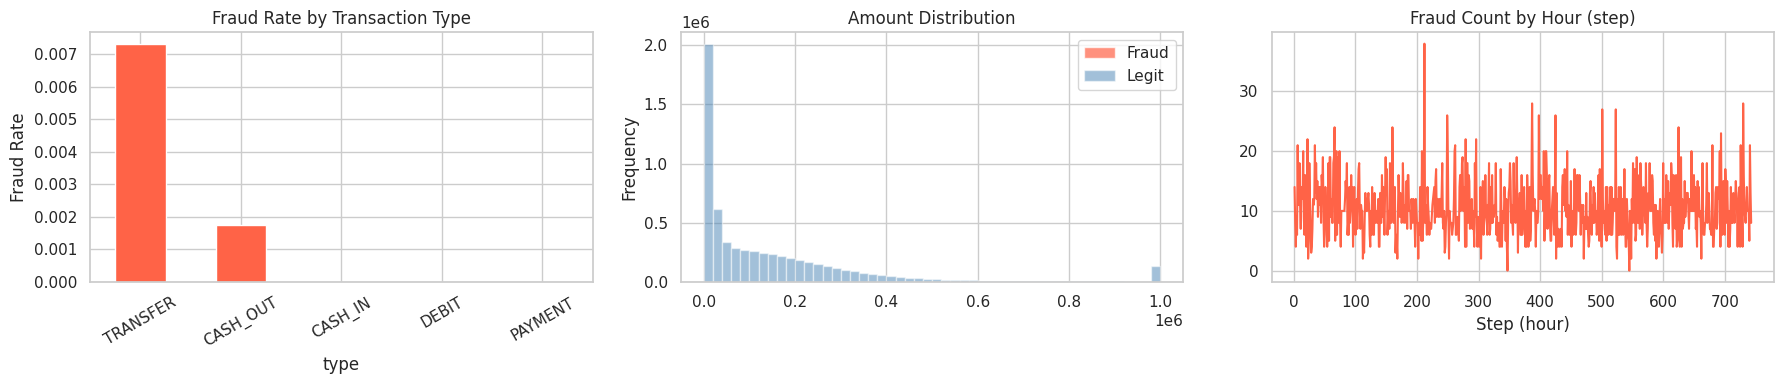

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df.groupby('type')['isFraud'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='tomato')
axes[0].set_title('Fraud Rate by Transaction Type')
axes[0].set_ylabel('Fraud Rate')
axes[0].tick_params(axis='x', rotation=30)

df[df['isFraud']==1]['amount'].clip(upper=1e6).plot(
    kind='hist', bins=50, ax=axes[1], color='tomato', alpha=0.7, label='Fraud')
df[df['isFraud']==0]['amount'].clip(upper=1e6).plot(
    kind='hist', bins=50, ax=axes[1], color='steelblue', alpha=0.5, label='Legit')
axes[1].set_title('Amount Distribution')
axes[1].legend()

df.groupby('step')['isFraud'].sum().plot(ax=axes[2], color='tomato')
axes[2].set_title('Fraud Count by Hour (step)')
axes[2].set_xlabel('Step (hour)')

plt.tight_layout()
plt.show()

## 5. Feature Engineering
Note: `orig_balance_error` and `dest_balance_error` are dropped — they are mathematically
derived and create a perfect boundary. Only business-logic features are kept.


In [5]:
def engineer_features(df):
    df = df.copy()

    # Ratio of amount to sender balance — how much was drained
    df['balance_drain_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

    # Was the sender account fully drained?
    df['is_full_drain'] = ((df['newbalanceOrig'] <= 1.0) & (df['oldbalanceOrg'] > 0)).astype(int)

    # Destination account had zero balance before receiving
    df['dest_was_empty'] = (df['oldbalanceDest'] <= 1.0).astype(int)

    # Destination balance is still zero after receiving (money moved on immediately)
    df['dest_still_empty'] = (df['newbalanceDest'] <= 1.0).astype(int)

    # Transaction type flags
    df['is_transfer'] = (df['type'] == 'TRANSFER').astype(int)
    df['is_cash_out'] = (df['type'] == 'CASH_OUT').astype(int)

    # Encode type
    df['type'] = LabelEncoder().fit_transform(df['type'])

    # Time features
    df['hour_of_day'] = df['step'] % 24
    df['is_night']    = ((df['hour_of_day'] >= 0) & (df['hour_of_day'] <= 5)).astype(int)

    # Log-scale amount (less extreme values)
    df['log_amount'] = np.log1p(df['amount'])

    return df

df = engineer_features(df)
print('Shape after engineering:', df.shape)

# Show how overlapping the key features now are
print('\nFeature means by class (closer = harder for model):')
check_cols = ['balance_drain_ratio', 'is_full_drain', 'dest_was_empty', 'dest_still_empty']
print(df.groupby('isFraud')[check_cols].mean().round(3))

Shape after engineering: (6362620, 20)

Feature means by class (closer = harder for model):


         balance_drain_ratio  is_full_drain  dest_was_empty  dest_still_empty
isFraud                                                                      
0                  52223.162          0.201           0.221             0.200
1                   1108.457          0.477           0.342             0.257


## 6. Prepare X, y

In [6]:
drop_cols = ['nameOrig', 'nameDest', 'isFlaggedFraud']
target    = 'isFraud'

X = df.drop(columns=drop_cols + [target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train fraud: {y_train.sum():,}  |  Test fraud: {y_test.sum():,}')
print(f'Features ({len(X.columns)}): {list(X.columns)}')

Train: (5090096, 16)  |  Test: (1272524, 16)
Train fraud: 6,242  |  Test fraud: 1,561
Features (16): ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balance_drain_ratio', 'is_full_drain', 'dest_was_empty', 'dest_still_empty', 'is_transfer', 'is_cash_out', 'hour_of_day', 'is_night', 'log_amount']


## 7. Train Models

In [7]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {pos_weight:.1f}')

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        n_jobs=-1, random_state=42, max_depth=12
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        scale_pos_weight=pos_weight,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42,
        verbosity=0, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        scale_pos_weight=pos_weight,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1, n_jobs=-1
    ),
}

results  = []
trained  = {}

for name, model in models.items():
    print(f'\nTraining {name}...')
    model.fit(X_train, y_train)
    trained[name] = model

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    roc     = roc_auc_score(y_test, y_proba)
    pr      = average_precision_score(y_test, y_proba)
    rep     = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Model':     name,
        'ROC-AUC':   round(roc, 4),
        'PR-AUC':    round(pr,  4),
        'Precision': round(rep['1']['precision'], 4),
        'Recall':    round(rep['1']['recall'],    4),
        'F1-Score':  round(rep['1']['f1-score'],  4),
        'Accuracy':  round(rep['accuracy'],       4),
    })
    print(f'  ROC-AUC={roc:.4f} | PR-AUC={pr:.4f} | F1={rep["1"]["f1-score"]:.4f}')

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print('\n=== Final Leaderboard ===')
results_df

scale_pos_weight: 814.5

Training Logistic Regression...


  ROC-AUC=0.9892 | PR-AUC=0.5406 | F1=0.0425

Training Random Forest...


  ROC-AUC=0.9963 | PR-AUC=0.7558 | F1=0.1331

Training XGBoost...


  ROC-AUC=0.9975 | PR-AUC=0.8373 | F1=0.1276

Training LightGBM...


  ROC-AUC=0.9687 | PR-AUC=0.0408 | F1=0.0637

=== Final Leaderboard ===


,Model,ROC-AUC,PR-AUC,Precision,Recall,F1-Score,Accuracy
0,XGBoost,0.9975,0.8373,0.0684,0.9596,0.1276,0.9839
1,Random Forest,0.9963,0.7558,0.0717,0.9353,0.1331,0.9851
2,Logistic Regression,0.9892,0.5406,0.0217,0.9385,0.0425,0.9481
3,LightGBM,0.9687,0.0408,0.0330,0.9481,0.0637,0.9658


## 8. Model Comparison Plots

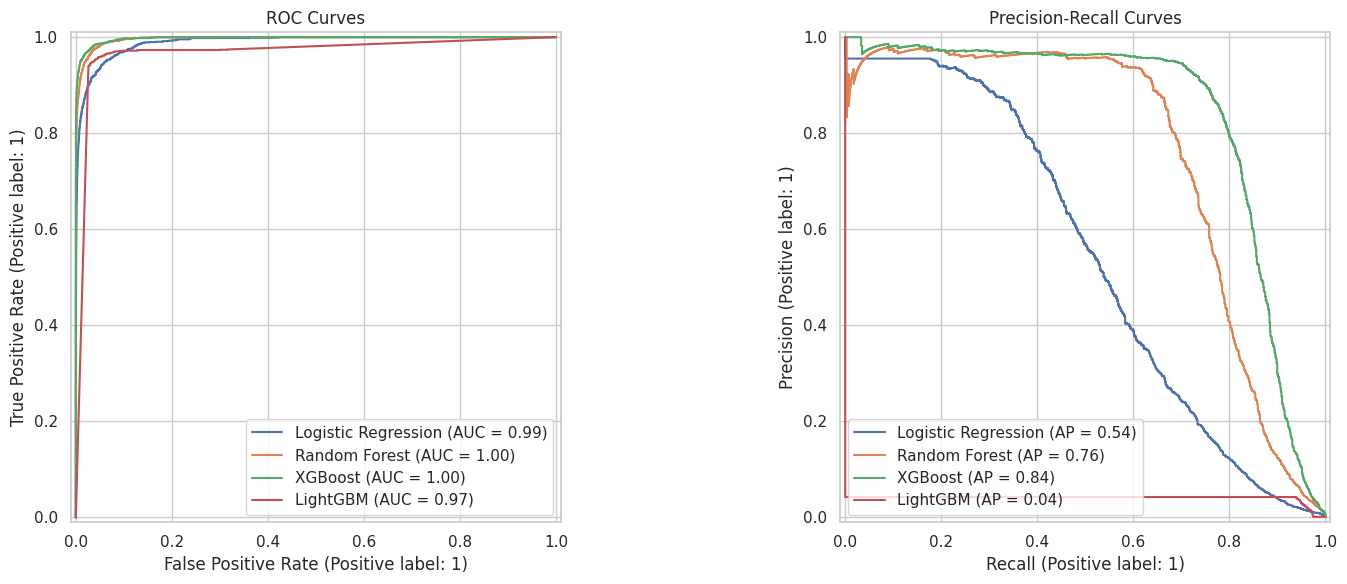

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, model in trained.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, y_proba, name=name, ax=axes[1])
axes[0].set_title('ROC Curves')
axes[1].set_title('Precision-Recall Curves')
plt.tight_layout()
plt.show()

## 9. Best Model Deep Dive

In [9]:
best_name  = results_df.iloc[0]['Model']
best_model = trained[best_name]
print(f'Best model: {best_name}')

y_pred_best  = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_best, target_names=['Legit','Fraud']))

Best model: XGBoost


              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99   1270963
       Fraud       0.07      0.96      0.13      1561

    accuracy                           0.98   1272524
   macro avg       0.53      0.97      0.56   1272524
weighted avg       1.00      0.98      0.99   1272524



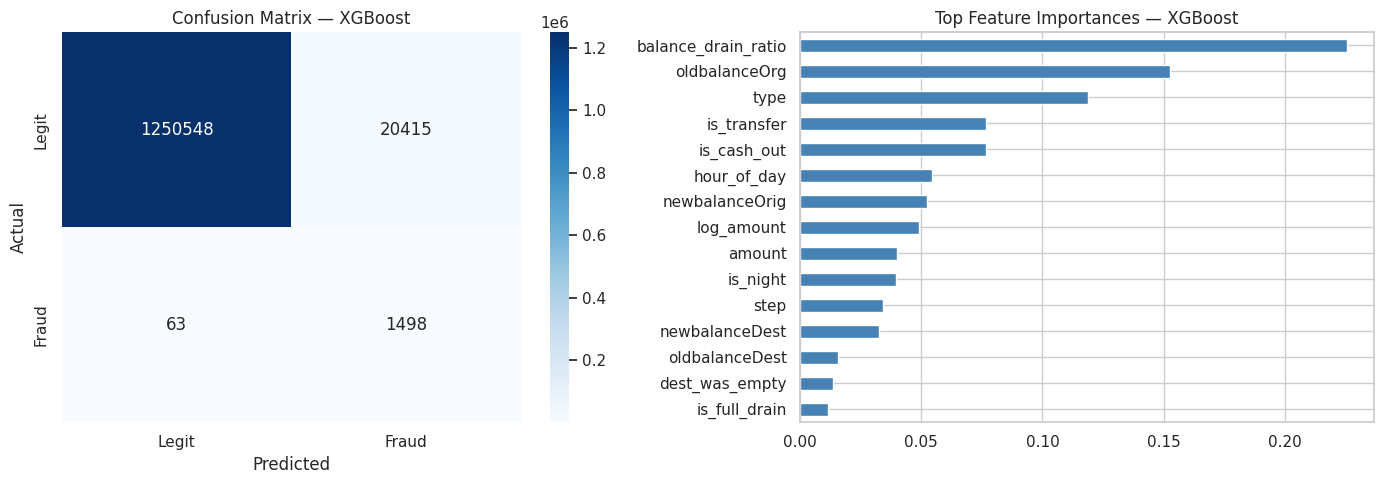

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
axes[0].set_title(f'Confusion Matrix — {best_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=X.columns)
else:
    imp = pd.Series(best_model.named_steps['clf'].coef_[0], index=X.columns).abs()
imp.sort_values().tail(15).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title(f'Top Feature Importances — {best_name}')

plt.tight_layout()
plt.show()

## 10. Save Best Model

In [11]:
os.makedirs('saved_models', exist_ok=True)

path = f'saved_models/fulldata_best_{best_name.lower().replace(" ","_")}.pkl'
joblib.dump(best_model, path)
results_df.to_csv('saved_models/fulldata_leaderboard.csv', index=False)

print(f'Model saved     → {path}')
print(f'Leaderboard     → saved_models/fulldata_leaderboard.csv')

m = joblib.load(path)
sample = X_test.iloc[:5]
print(f'\nVerify probs : {m.predict_proba(sample)[:,1].round(4)}')
print(f'Actual labels: {y_test.iloc[:5].values}')

Model saved     → saved_models/fulldata_best_xgboost.pkl
Leaderboard     → saved_models/fulldata_leaderboard.csv

Verify probs : [0.0029 0.0011 0.0002 0.0011 0.0002]
Actual labels: [0 0 0 0 0]
